# Question 2: Super-Advanced Equal-Elo Opening Repertoire Model

This notebook develops a stronger predictive pipeline for Question 2: forecasting **win, loss, and draw probabilities** in matchups between players of nearly equal Elo, while isolating the strategic effect of their historical opening repertoires.


## What Makes This Version Super-Advanced
1. It uses only **first-time matchups** to avoid repeated-opponent leakage.
2. It restricts the model to **equal-Elo games** using a small Elo tolerance window.
3. It builds **pre-game historical repertoire features** so every prediction uses only information available before the game happened.
4. It combines structured repertoire statistics with **TF-IDF opening-history text features**.
5. It compresses those high-dimensional repertoire histories with **TruncatedSVD**.
6. It trains a tuned **multiclass HistGradientBoostingClassifier** to predict calibrated win/loss/draw probabilities.
7. It evaluates the model with **multiclass log loss, Brier-style probability diagnostics, and confusion matrix**.


In [1]:
import os
import warnings
from collections import Counter, defaultdict
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, log_loss
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


In [2]:
DATA_PATH = Path('/Users/phamhoanghai/Ureca/dataset/final_data')
OUTPUT_DIR = Path('/Users/phamhoanghai/Ureca/Question_two/advanced_output')
PLOT_DIR = Path('/Users/phamhoanghai/Ureca/Question_two/advanced_plots')

COLUMN_MAP = {
    'game_id': 'GameID',
    'white_player': 'White',
    'black_player': 'Black',
    'white_elo': 'WhiteEloNumeric',
    'black_elo': 'BlackEloNumeric',
    'result': 'Result',
    'opening_name': 'Opening',
    'opening_family': 'OpeningFamily',
}

MIN_TOTAL_GAMES_PER_PLAYER = 20
MIN_HISTORY_GAMES = 10
ELO_TOLERANCE = 25
TOP_OPENINGS_IN_CORPUS = 8
TOP_FAMILIES_IN_CORPUS = 4
TEST_SIZE_FRACTION = 0.20
RANDOM_STATE = 42
TEXT_MAX_FEATURES = 1500
TEXT_SVD_COMPONENTS = 30

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(DATA_PATH)
print(DATA_PATH.exists())


/Users/phamhoanghai/Ureca/dataset/final_data
True


## Load And Standardize The Full Dataset


In [3]:
def map_result_to_class(result_series: pd.Series) -> pd.Series:
    s = result_series.astype(str).str.strip()
    mapping = {
        '1-0': 'win',
        '0-1': 'loss',
        '1/2-1/2': 'draw',
        '0.5-0.5': 'draw',
        '1': 'win',
        '0': 'loss',
        '0.5': 'draw',
        'win': 'win',
        'loss': 'loss',
        'draw': 'draw',
    }
    return s.map(mapping)


def standardize_schema(df: pd.DataFrame, column_map: dict) -> pd.DataFrame:
    reverse_map = {v: k for k, v in column_map.items() if v in df.columns}
    out = df.rename(columns=reverse_map).copy()

    required = [
        'game_id', 'white_player', 'black_player', 'white_elo', 'black_elo', 'result', 'opening_name'
    ]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    if 'opening_family' not in out.columns:
        out['opening_family'] = 'Unknown'

    out['game_id'] = pd.to_numeric(out['game_id'], errors='coerce')
    out['white_elo'] = pd.to_numeric(out['white_elo'], errors='coerce')
    out['black_elo'] = pd.to_numeric(out['black_elo'], errors='coerce')
    out['outcome'] = map_result_to_class(out['result'])
    out = out.dropna(subset=['game_id', 'white_player', 'black_player', 'white_elo', 'black_elo', 'opening_name', 'outcome'])
    out = out.sort_values(['game_id', 'white_player', 'black_player'], kind='mergesort').reset_index(drop=True)
    out['elo_diff'] = out['white_elo'] - out['black_elo']
    out['abs_elo_diff'] = out['elo_diff'].abs()
    out['avg_elo'] = (out['white_elo'] + out['black_elo']) / 2
    out['eco_group'] = out['opening_name'].astype(str)
    return out

raw_df = pd.read_csv(DATA_PATH)
df = standardize_schema(raw_df, COLUMN_MAP)
print('Loaded standardized shape:', df.shape)
df.head()


Loaded standardized shape: (1111082, 18)


,game_id,Event,white_player,black_player,white_elo,black_elo,ECO,opening_name,EloDiff,AvgElo,result,NumericResult,opening_family,outcome,elo_diff,abs_elo_diff,avg_elo,eco_group
0,1,Rated Bullet game,sisy,lpaulmp,1645.0,1449.0,D31,Queen's Gambit Declined: Queen's Knight Variation,196.0,1547.0,1-0,1.0,Closed and Semi-Closed,win,196.0,196.0,1547.0,Queen's Gambit Declined: Queen's Knight Variation
1,2,Rated Blitz game,capablanca1950,ftri67,1603.0,1672.0,C00,French Defense,-69.0,1637.5,0-1,0.0,Open Games and Semi-Open,loss,-69.0,69.0,1637.5,French Defense
2,3,Rated Bullet game,daamien,mike81,1166.0,1280.0,D00,Queen's Pawn Game: Steinitz Countergambit,-114.0,1223.0,1-0,1.0,Closed and Semi-Closed,win,-114.0,114.0,1223.0,Queen's Pawn Game: Steinitz Countergambit
3,4,Rated Blitz game,yaavarmo,JACKELCALVO,1494.0,1449.0,C00,French Defense: Normal Variation,45.0,1471.5,1-0,1.0,Open Games and Semi-Open,win,45.0,45.0,1471.5,French Defense: Normal Variation
4,5,Rated Bullet game,albinofrenchy,galita,1256.0,1285.0,D53,Queen's Gambit Declined: 4.Bg5 Be7,-29.0,1270.5,1-0,1.0,Closed and Semi-Closed,win,-29.0,29.0,1270.5,Queen's Gambit Declined: 4.Bg5 Be7


In [4]:
player_counts = pd.concat([df['white_player'], df['black_player']], ignore_index=True).value_counts()
frequent_players = player_counts[player_counts >= MIN_TOTAL_GAMES_PER_PLAYER].index

frequent_df = df[
    df['white_player'].isin(frequent_players)
    & df['black_player'].isin(frequent_players)
].copy()

print('Frequent players:', len(frequent_players))
print('Games between frequent players:', len(frequent_df))


Frequent players: 12888
Games between frequent players: 1025440


## Build Strict Pre-Game Repertoire Histories
This step is the core of the isolation strategy. For every game, we build each player's repertoire summary **using only games played before that game**.


In [5]:
def shannon_entropy_from_counter(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0:
        return np.nan
    probs = np.array(list(counter.values()), dtype=float) / total
    return float(-(probs * np.log2(probs)).sum())


def extract_top_item(counter: Counter):
    if not counter:
        return 'Unknown', 0
    item, count = max(counter.items(), key=lambda kv: (kv[1], kv[0]))
    return item, count


def top_counter_corpus(counter: Counter, top_n: int) -> str:
    if not counter:
        return 'unknown'
    parts = []
    for item, count in counter.most_common(top_n):
        clean_item = str(item).replace(':', ' ').replace(',', ' ').replace(';', ' ')
        repeat = max(1, min(int(count), 12))
        parts.extend([clean_item] * repeat)
    return ' ; '.join(parts) if parts else 'unknown'


def counter_overlap_ratio(counter_a: Counter, counter_b: Counter) -> float:
    if not counter_a or not counter_b:
        return 0.0
    set_a = set(counter_a.keys())
    set_b = set(counter_b.keys())
    union = set_a | set_b
    if not union:
        return 0.0
    return len(set_a & set_b) / len(union)


def opposite_outcome(outcome: str) -> str:
    if outcome == 'win':
        return 'loss'
    if outcome == 'loss':
        return 'win'
    return 'draw'


def build_pre_game_history_features(df: pd.DataFrame) -> pd.DataFrame:
    player_stats = defaultdict(lambda: {
        'games': 0,
        'openings': Counter(),
        'families': Counter(),
        'results': Counter(),
    })
    matchup_counts = Counter()
    rows = []

    for row in df.itertuples(index=False):
        white_stats = player_stats[row.white_player]
        black_stats = player_stats[row.black_player]
        matchup_key = tuple(sorted((row.white_player, row.black_player)))

        white_top_opening, white_top_opening_games = extract_top_item(white_stats['openings'])
        black_top_opening, black_top_opening_games = extract_top_item(black_stats['openings'])
        white_top_family, white_top_family_games = extract_top_item(white_stats['families'])
        black_top_family, black_top_family_games = extract_top_item(black_stats['families'])

        white_games = white_stats['games']
        black_games = black_stats['games']

        white_opening_entropy = shannon_entropy_from_counter(white_stats['openings'])
        black_opening_entropy = shannon_entropy_from_counter(black_stats['openings'])
        white_family_entropy = shannon_entropy_from_counter(white_stats['families'])
        black_family_entropy = shannon_entropy_from_counter(black_stats['families'])

        white_win_rate = white_stats['results']['win'] / white_games if white_games else np.nan
        black_win_rate = black_stats['results']['win'] / black_games if black_games else np.nan
        white_draw_rate = white_stats['results']['draw'] / white_games if white_games else np.nan
        black_draw_rate = black_stats['results']['draw'] / black_games if black_games else np.nan
        white_loss_rate = white_stats['results']['loss'] / white_games if white_games else np.nan
        black_loss_rate = black_stats['results']['loss'] / black_games if black_games else np.nan

        white_top_opening_share = white_top_opening_games / white_games if white_games else np.nan
        black_top_opening_share = black_top_opening_games / black_games if black_games else np.nan
        white_top_family_share = white_top_family_games / white_games if white_games else np.nan
        black_top_family_share = black_top_family_games / black_games if black_games else np.nan

        white_opening_corpus = top_counter_corpus(white_stats['openings'], TOP_OPENINGS_IN_CORPUS)
        black_opening_corpus = top_counter_corpus(black_stats['openings'], TOP_OPENINGS_IN_CORPUS)
        white_family_corpus = top_counter_corpus(white_stats['families'], TOP_FAMILIES_IN_CORPUS)
        black_family_corpus = top_counter_corpus(black_stats['families'], TOP_FAMILIES_IN_CORPUS)

        rows.append({
            'game_id': row.game_id,
            'white_player': row.white_player,
            'black_player': row.black_player,
            'white_elo': row.white_elo,
            'black_elo': row.black_elo,
            'avg_elo': row.avg_elo,
            'elo_diff': row.elo_diff,
            'abs_elo_diff': row.abs_elo_diff,
            'opening_name': row.opening_name,
            'opening_family': row.opening_family,
            'outcome': row.outcome,
            'prior_matchups': matchup_counts[matchup_key],
            'white_history_games': white_games,
            'black_history_games': black_games,
            'white_unique_openings': len(white_stats['openings']),
            'black_unique_openings': len(black_stats['openings']),
            'white_unique_families': len(white_stats['families']),
            'black_unique_families': len(black_stats['families']),
            'white_opening_entropy': white_opening_entropy,
            'black_opening_entropy': black_opening_entropy,
            'white_family_entropy': white_family_entropy,
            'black_family_entropy': black_family_entropy,
            'white_top_opening': white_top_opening,
            'black_top_opening': black_top_opening,
            'white_top_family': white_top_family,
            'black_top_family': black_top_family,
            'white_top_opening_share': white_top_opening_share,
            'black_top_opening_share': black_top_opening_share,
            'white_top_family_share': white_top_family_share,
            'black_top_family_share': black_top_family_share,
            'white_prior_win_rate': white_win_rate,
            'black_prior_win_rate': black_win_rate,
            'white_prior_draw_rate': white_draw_rate,
            'black_prior_draw_rate': black_draw_rate,
            'white_prior_loss_rate': white_loss_rate,
            'black_prior_loss_rate': black_loss_rate,
            'same_top_opening': int(white_top_opening == black_top_opening and white_top_opening != 'Unknown'),
            'same_top_family': int(white_top_family == black_top_family and white_top_family != 'Unknown'),
            'opening_overlap_ratio': counter_overlap_ratio(white_stats['openings'], black_stats['openings']),
            'family_overlap_ratio': counter_overlap_ratio(white_stats['families'], black_stats['families']),
            'white_opening_corpus': white_opening_corpus,
            'black_opening_corpus': black_opening_corpus,
            'white_family_corpus': white_family_corpus,
            'black_family_corpus': black_family_corpus,
        })

        white_stats['games'] += 1
        black_stats['games'] += 1
        white_stats['openings'][row.opening_name] += 1
        black_stats['openings'][row.opening_name] += 1
        white_stats['families'][row.opening_family] += 1
        black_stats['families'][row.opening_family] += 1
        white_stats['results'][row.outcome] += 1
        black_stats['results'][opposite_outcome(row.outcome)] += 1
        matchup_counts[matchup_key] += 1

    out = pd.DataFrame(rows)
    out['entropy_gap'] = out['white_opening_entropy'] - out['black_opening_entropy']
    out['family_entropy_gap'] = out['white_family_entropy'] - out['black_family_entropy']
    out['diversity_gap'] = out['white_unique_openings'] - out['black_unique_openings']
    out['family_diversity_gap'] = out['white_unique_families'] - out['black_unique_families']
    out['specialization_gap'] = out['white_top_opening_share'] - out['black_top_opening_share']
    out['family_focus_gap'] = out['white_top_family_share'] - out['black_top_family_share']
    out['win_rate_gap'] = out['white_prior_win_rate'] - out['black_prior_win_rate']
    out['draw_rate_gap'] = out['white_prior_draw_rate'] - out['black_prior_draw_rate']
    out['loss_rate_gap'] = out['white_prior_loss_rate'] - out['black_prior_loss_rate']
    return out

history_df = build_pre_game_history_features(frequent_df)
print('History feature rows:', history_df.shape)
history_df.head()


History feature rows: (1025440, 53)


,game_id,white_player,black_player,white_elo,black_elo,avg_elo,elo_diff,abs_elo_diff,opening_name,opening_family,outcome,prior_matchups,white_history_games,black_history_games,white_unique_openings,black_unique_openings,white_unique_families,black_unique_families,white_opening_entropy,black_opening_entropy,white_family_entropy,black_family_entropy,white_top_opening,black_top_opening,white_top_family,black_top_family,white_top_opening_share,black_top_opening_share,white_top_family_share,black_top_family_share,white_prior_win_rate,black_prior_win_rate,white_prior_draw_rate,black_prior_draw_rate,white_prior_loss_rate,black_prior_loss_rate,same_top_opening,same_top_family,opening_overlap_ratio,family_overlap_ratio,white_opening_corpus,black_opening_corpus,white_family_corpus,black_family_corpus,entropy_gap,family_entropy_gap,diversity_gap,family_diversity_gap,specialization_gap,family_focus_gap,win_rate_gap,draw_rate_gap,loss_rate_gap
0,1,sisy,lpaulmp,1645.0,1449.0,1547.0,196.0,196.0,Queen's Gambit Declined: Queen's Knight Variation,Closed and Semi-Closed,win,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0.0,unknown,unknown,unknown,unknown,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
1,2,capablanca1950,ftri67,1603.0,1672.0,1637.5,-69.0,69.0,French Defense,Open Games and Semi-Open,loss,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0.0,unknown,unknown,unknown,unknown,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
2,3,daamien,mike81,1166.0,1280.0,1223.0,-114.0,114.0,Queen's Pawn Game: Steinitz Countergambit,Closed and Semi-Closed,win,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0.0,unknown,unknown,unknown,unknown,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
3,4,yaavarmo,JACKELCALVO,1494.0,1449.0,1471.5,45.0,45.0,French Defense: Normal Variation,Open Games and Semi-Open,win,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0.0,unknown,unknown,unknown,unknown,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN
4,5,albinofrenchy,galita,1256.0,1285.0,1270.5,-29.0,29.0,Queen's Gambit Declined: 4.Bg5 Be7,Closed and Semi-Closed,win,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0.0,unknown,unknown,unknown,unknown,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN


## Isolate Equal-Elo First-Time Matchups
To isolate repertoire advantage rather than rating advantage, we keep only:
- first-time meetings
- players with enough prior history
- Elo difference within a narrow tolerance window


In [6]:
first_time_df = history_df[history_df['prior_matchups'] == 0].copy()
equal_elo_df = first_time_df[
    (first_time_df['white_history_games'] >= MIN_HISTORY_GAMES)
    & (first_time_df['black_history_games'] >= MIN_HISTORY_GAMES)
    & (first_time_df['abs_elo_diff'] <= ELO_TOLERANCE)
].copy()

print('First-time matchup rows:', len(first_time_df))
print('Equal-Elo model rows:', len(equal_elo_df))
print(equal_elo_df['outcome'].value_counts(dropna=False))
equal_elo_df.head()


First-time matchup rows: 574565
Equal-Elo model rows: 68959
outcome
win     33987
loss    31950
draw     3022
Name: count, dtype: int64


,game_id,white_player,black_player,white_elo,black_elo,avg_elo,elo_diff,abs_elo_diff,opening_name,opening_family,outcome,prior_matchups,white_history_games,black_history_games,white_unique_openings,black_unique_openings,white_unique_families,black_unique_families,white_opening_entropy,black_opening_entropy,white_family_entropy,black_family_entropy,white_top_opening,black_top_opening,white_top_family,black_top_family,white_top_opening_share,black_top_opening_share,white_top_family_share,black_top_family_share,white_prior_win_rate,black_prior_win_rate,white_prior_draw_rate,black_prior_draw_rate,white_prior_loss_rate,black_prior_loss_rate,same_top_opening,same_top_family,opening_overlap_ratio,family_overlap_ratio,white_opening_corpus,black_opening_corpus,white_family_corpus,black_family_corpus,entropy_gap,family_entropy_gap,diversity_gap,family_diversity_gap,specialization_gap,family_focus_gap,win_rate_gap,draw_rate_gap,loss_rate_gap
1691,1899,Zzorro,bombozik,1722.0,1740.0,1731.0,-18.0,18.0,French Defense: Two Knights Variation,Open Games and Semi-Open,loss,0,17,33,16,18,4,4,3.969816,3.819959,1.865437,1.661882,Vienna Game: Max Lange Defense,Queen's Pawn Game #2,Semi-Open Defenses,Flank Openings,0.117647,0.212121,0.352941,0.454545,0.176471,0.242424,0.176471,0.151515,0.647059,0.606061,0,0,0.096774,1.00,Vienna Game Max Lange Defense ; Vienna Game ...,Queen's Pawn Game #2 ; Queen's Pawn Game #2 ; ...,Semi-Open Defenses ; Semi-Open Defenses ; Semi...,Flank Openings ; Flank Openings ; Flank Openin...,0.149857,0.203555,-2,0,-0.094474,-0.101604,-0.065954,0.024955,0.040998
2344,2629,INTIWATANA,patrick03,1551.0,1569.0,1560.0,-18.0,18.0,Scandinavian Defense: Modern Variation #2,Semi-Open Defenses,win,0,25,21,22,17,3,4,4.323856,4.011365,1.461901,1.717041,Englund Gambit Complex: Englund Gambit,Van't Kruijs Opening,Open Games and Semi-Open,Open Games and Semi-Open,0.160000,0.095238,0.480000,0.428571,0.480000,0.380952,0.080000,0.047619,0.440000,0.571429,0,1,0.026316,0.75,Englund Gambit Complex Englund Gambit ; Englu...,Van't Kruijs Opening ; Van't Kruijs Opening ; ...,Open Games and Semi-Open ; Open Games and Semi...,Open Games and Semi-Open ; Open Games and Semi...,0.312491,-0.255140,5,-1,0.064762,0.051429,0.099048,0.032381,-0.131429
2893,3281,grasshopper,cocochess,1830.0,1811.0,1820.5,19.0,19.0,Sicilian Defense: Smith-Morra Gambit #2,Semi-Open Defenses,loss,0,18,14,14,10,3,3,3.614369,3.182006,1.122114,0.946373,Modern Defense,Sicilian Defense #2,Semi-Open Defenses,Semi-Open Defenses,0.222222,0.214286,0.722222,0.785714,0.611111,0.714286,0.055556,0.000000,0.333333,0.285714,0,1,0.043478,1.00,Modern Defense ; Modern Defense ; Modern Defen...,Sicilian Defense #2 ; Sicilian Defense #2 ; Si...,Semi-Open Defenses ; Semi-Open Defenses ; Semi...,Semi-Open Defenses ; Semi-Open Defenses ; Semi...,0.432364,0.175741,4,0,0.007937,-0.063492,-0.103175,0.055556,0.047619
2950,3347,Laisha,shuntandromeda1,1622.0,1636.0,1629.0,-14.0,14.0,Horwitz Defense,Flank Openings,loss,0,12,21,8,18,3,3,2.855389,4.106603,1.188722,1.493710,Owen Defense,French Defense: Knight Variation,Flank Openings,Open Games and Semi-Open,0.250000,0.095238,0.666667,0.476190,0.750000,0.380952,0.000000,0.047619,0.250000,0.571429,0,0,0.000000,1.00,Owen Defense ; Owen Defense ; Owen Defense ; E...,French Defense Knight Variation ; French Defe...,Flank Openings ; Flank Openings ; Flank Openin...,Open Games and Semi-Open ; Open Games and Semi...,-1.251215,-0.304988,-10,0,0.154762,0.190476,0.369048,-0.047619,-0.321429
3380,3827,subteacher,Aurorachess58,1815.0,1828.0,1821.5,-13.0,13.0,French Defense #2,Open Games and Semi-Open,loss,0,24,31,13,16,4,3,3.266151,3.471159,0.741685,1.273367,Sicilian Defense,Mieses Opening,Semi-Open Defenses,Flank Openings,0.291667,0.322581,0.875000,0.516129,0.291667,0.741935,0.000000,0.032258,0.708333,0.225806,0,0,0.000000,0.75,Sicilian Defense ; Sicilian Defense ; Sicilian...,Mieses Opening ; Mieses Opening ; Mieses Openi...,Semi-Open Defenses ; Semi-Open Defenses ; Semi...

## Feature Design For The Predictive Model
The model intentionally excludes raw player identity and uses opening-history structure instead. It also avoids using large Elo asymmetry as a shortcut, because the dataset has already been filtered to near-equal Elo games.


In [7]:
NUM_FEATURES = [
    'white_history_games',
    'black_history_games',
    'avg_elo',
    'abs_elo_diff',
    'white_unique_openings',
    'black_unique_openings',
    'white_unique_families',
    'black_unique_families',
    'white_opening_entropy',
    'black_opening_entropy',
    'white_family_entropy',
    'black_family_entropy',
    'white_top_opening_share',
    'black_top_opening_share',
    'white_top_family_share',
    'black_top_family_share',
    'white_prior_win_rate',
    'black_prior_win_rate',
    'white_prior_draw_rate',
    'black_prior_draw_rate',
    'white_prior_loss_rate',
    'black_prior_loss_rate',
    'entropy_gap',
    'family_entropy_gap',
    'diversity_gap',
    'family_diversity_gap',
    'specialization_gap',
    'family_focus_gap',
    'win_rate_gap',
    'draw_rate_gap',
    'loss_rate_gap',
    'same_top_opening',
    'same_top_family',
    'opening_overlap_ratio',
    'family_overlap_ratio',
]

TARGET_COL = 'outcome'
CLASS_ORDER = ['win', 'draw', 'loss']

model_df = equal_elo_df.sort_values('game_id').reset_index(drop=True).copy()
print(model_df.shape)


(68959, 53)


## Chronological Train/Test Split
We split by game order rather than randomly, so the test set represents genuinely later matchups.


In [8]:
split_idx = int(len(model_df) * (1 - TEST_SIZE_FRACTION))
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train outcome distribution:')
print(train_df[TARGET_COL].value_counts(normalize=True))
print('Test outcome distribution:')
print(test_df[TARGET_COL].value_counts(normalize=True))


Train rows: 55167
Test rows: 13792
Train outcome distribution:
outcome
win     0.493121
loss    0.462505
draw    0.044374
Name: proportion, dtype: float64
Test outcome distribution:
outcome
win     0.491807
loss    0.466575
draw    0.041618
Name: proportion, dtype: float64


## Build Hybrid Structured + Text Repertoire Features
We vectorize each player's opening-history and family-history text separately, reduce them with SVD, then join them with scaled structured features.


In [9]:
def fit_text_block(train_series: pd.Series, test_series: pd.Series, max_features: int, n_components: int, prefix: str):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=3,
        max_features=max_features,
    )
    X_train_tfidf = vectorizer.fit_transform(train_series.fillna('unknown'))
    X_test_tfidf = vectorizer.transform(test_series.fillna('unknown'))

    actual_components = min(n_components, max(2, X_train_tfidf.shape[1] - 1))
    svd = TruncatedSVD(n_components=actual_components, random_state=RANDOM_STATE)
    X_train_svd = svd.fit_transform(X_train_tfidf)
    X_test_svd = svd.transform(X_test_tfidf)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_svd)
    X_test_scaled = scaler.transform(X_test_svd)

    col_names = [f'{prefix}_svd_{i+1}' for i in range(actual_components)]
    train_df_out = pd.DataFrame(X_train_scaled, columns=col_names, index=train_series.index)
    test_df_out = pd.DataFrame(X_test_scaled, columns=col_names, index=test_series.index)
    return train_df_out, test_df_out, vectorizer, svd

num_imputer = SimpleImputer(strategy='median')
num_scaler = StandardScaler()

X_train_num = pd.DataFrame(
    num_scaler.fit_transform(num_imputer.fit_transform(train_df[NUM_FEATURES])),
    columns=NUM_FEATURES,
    index=train_df.index,
)
X_test_num = pd.DataFrame(
    num_scaler.transform(num_imputer.transform(test_df[NUM_FEATURES])),
    columns=NUM_FEATURES,
    index=test_df.index,
)

text_blocks = [
    ('white_openings', 'white_opening_corpus'),
    ('black_openings', 'black_opening_corpus'),
    ('white_families', 'white_family_corpus'),
    ('black_families', 'black_family_corpus'),
]

train_parts = [X_train_num]
test_parts = [X_test_num]
text_artifacts = {}

for prefix, col in text_blocks:
    tr_block, te_block, vec, svd = fit_text_block(
        train_df[col],
        test_df[col],
        max_features=TEXT_MAX_FEATURES,
        n_components=TEXT_SVD_COMPONENTS,
        prefix=prefix,
    )
    train_parts.append(tr_block)
    test_parts.append(te_block)
    text_artifacts[prefix] = {'vectorizer': vec, 'svd': svd}

X_train = pd.concat(train_parts, axis=1)
X_test = pd.concat(test_parts, axis=1)

y_train = train_df[TARGET_COL].copy()
y_test = test_df[TARGET_COL].copy()

label_encoder = LabelEncoder()
label_encoder.fit(CLASS_ORDER)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print('Final train matrix:', X_train.shape)
print('Final test matrix:', X_test.shape)


Final train matrix: (55167, 155)
Final test matrix: (13792, 155)


## Tune And Train The Super-Advanced Model
We search over a compact but meaningful hyperparameter grid for multiclass histogram gradient boosting, optimizing validation log loss.


In [10]:
val_split_idx = int(len(X_train) * 0.85)
X_subtrain = X_train.iloc[:val_split_idx]
X_val = X_train.iloc[val_split_idx:]
y_subtrain = y_train_encoded[:val_split_idx]
y_val = y_train_encoded[val_split_idx:]

param_grid = {
    'learning_rate': [0.03, 0.05],
    'max_depth': [4, 6, None],
    'max_leaf_nodes': [31, 63],
    'min_samples_leaf': [20, 40],
    'l2_regularization': [0.0, 0.1],
}

search_rows = []
best_model = None
best_params = None
best_logloss = float('inf')

for params in ParameterGrid(param_grid):
    model = HistGradientBoostingClassifier(
        loss='log_loss',
        max_iter=300,
        early_stopping=True,
        validation_fraction=None,
        random_state=RANDOM_STATE,
        **params,
    )
    model.fit(X_subtrain, y_subtrain)
    val_pred = model.predict_proba(X_val)
    val_logloss = log_loss(y_val, val_pred, labels=np.arange(len(CLASS_ORDER)))
    search_rows.append({**params, 'val_log_loss': float(val_logloss)})

    if val_logloss < best_logloss:
        best_logloss = val_logloss
        best_model = model
        best_params = params

search_df = pd.DataFrame(search_rows).sort_values('val_log_loss').reset_index(drop=True)
print('Best validation log loss:', round(best_logloss, 5))
print('Best params:', best_params)
search_df.head(10)


Best validation log loss: 0.84175
Best params: {'l2_regularization': 0.1, 'learning_rate': 0.03, 'max_depth': 4, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}


,l2_regularization,learning_rate,max_depth,max_leaf_nodes,min_samples_leaf,val_log_loss
0,0.1,0.03,4.0,31,20,0.841754
1,0.1,0.03,4.0,63,20,0.841754
2,0.0,0.03,4.0,31,40,0.842055
3,0.0,0.03,4.0,63,40,0.842055
4,0.0,0.03,4.0,31,20,0.842295
5,0.0,0.03,4.0,63,20,0.842295
6,0.1,0.03,4.0,63,40,0.842308
7,0.1,0.03,4.0,31,40,0.842308
8,0.0,0.03,NaN,31,20,0.842763
9,0.0,0.03,NaN,31,40,0.843499


In [11]:
final_model = HistGradientBoostingClassifier(
    loss='log_loss',
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
    **best_params,
)
final_model.fit(X_train, y_train_encoded)

test_pred_proba = final_model.predict_proba(X_test)
test_pred = final_model.predict(X_test)
test_pred_labels = label_encoder.inverse_transform(test_pred)

multiclass_logloss = log_loss(y_test_encoded, test_pred_proba, labels=np.arange(len(CLASS_ORDER)))
conf_mat = confusion_matrix(y_test, test_pred_labels, labels=CLASS_ORDER)

prob_df = pd.DataFrame(test_pred_proba, columns=[f'prob_{c}' for c in label_encoder.classes_], index=test_df.index)
results_df = pd.concat([
    test_df[['game_id', 'white_player', 'black_player', 'white_elo', 'black_elo', 'opening_name', 'opening_family', 'outcome']].reset_index(drop=True),
    pd.Series(test_pred_labels, name='predicted_outcome'),
    prob_df.reset_index(drop=True),
], axis=1)

print('Test multiclass log loss:', round(multiclass_logloss, 5))
print(classification_report(y_test, test_pred_labels, labels=CLASS_ORDER))
results_df.head()


Test multiclass log loss: 0.83515
              precision    recall  f1-score   support

         win       0.50      0.86      0.63      6783
        draw       0.00      0.00      0.00       574
        loss       0.49      0.16      0.24      6435

    accuracy                           0.50     13792
   macro avg       0.33      0.34      0.29     13792
weighted avg       0.47      0.50      0.42     13792



,game_id,white_player,black_player,white_elo,black_elo,opening_name,opening_family,outcome,predicted_outcome,prob_draw,prob_loss,prob_win
0,899603,alecool2,babak48,1375.0,1397.0,Philidor Defense #2,Open Games and Semi-Open,loss,win,0.035802,0.464318,0.499881
1,899625,ogun,alab,1728.0,1733.0,"Sicilian Defense: Smith-Morra Gambit Declined,...",Semi-Open Defenses,win,win,0.032303,0.479953,0.487744
2,899650,formatc,nik59,1572.0,1593.0,Modern Defense,Semi-Open Defenses,loss,win,0.029235,0.461530,0.509235
3,899660,Hei,TransCanadaHighway,1655.0,1650.0,Caro-Kann Defense,Semi-Open Defenses,loss,win,0.042018,0.472698,0.485284
4,899671,persepolis46,elfomen,1665.0,1650.0,Queen's Pawn,Flank Openings,win,win,0.038738,0.469728,0.491534


## Probability Diagnostics


In [12]:
y_test_onehot = pd.get_dummies(y_test).reindex(columns=CLASS_ORDER, fill_value=0).to_numpy()
class_prob_columns = [f'prob_{c}' for c in CLASS_ORDER]
pred_prob_matrix = results_df[class_prob_columns].to_numpy()
multiclass_brier = np.mean(np.sum((pred_prob_matrix - y_test_onehot) ** 2, axis=1))

summary_metrics = pd.DataFrame({
    'metric': ['test_log_loss', 'multiclass_brier_score'],
    'value': [multiclass_logloss, multiclass_brier],
})
summary_metrics


,metric,value
0,test_log_loss,0.835150
1,multiclass_brier_score,0.538323


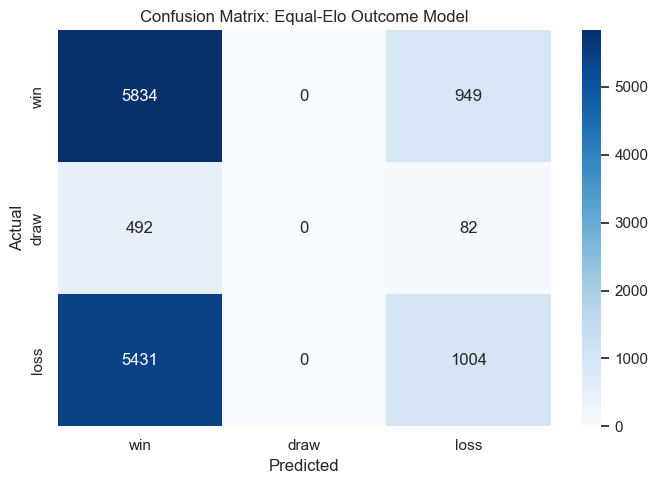

In [13]:
plt.figure(figsize=(7, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.title('Confusion Matrix: Equal-Elo Outcome Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


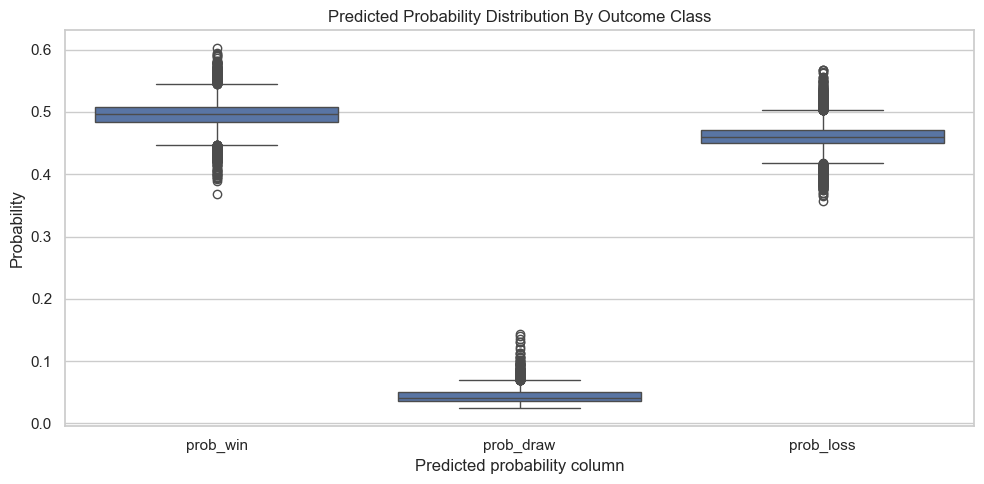

In [14]:
plot_df = results_df.melt(
    id_vars=['outcome'],
    value_vars=class_prob_columns,
    var_name='probability_type',
    value_name='probability',
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x='probability_type', y='probability')
plt.title('Predicted Probability Distribution By Outcome Class')
plt.xlabel('Predicted probability column')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()


## Which Repertoire Gaps Matter Most?
Histogram gradient boosting does not provide simple coefficients like logistic regression, so we use permutation-style loss impact on a selected subset of important structured features.


In [15]:
baseline_loss = log_loss(y_test_encoded, test_pred_proba, labels=np.arange(len(CLASS_ORDER)))
importance_rows = []
importance_features = [
    'specialization_gap',
    'family_focus_gap',
    'opening_overlap_ratio',
    'family_overlap_ratio',
    'win_rate_gap',
    'draw_rate_gap',
    'entropy_gap',
    'family_entropy_gap',
    'same_top_opening',
    'same_top_family',
]

rng = np.random.default_rng(RANDOM_STATE)
X_test_perm = X_test.copy()

for feature in importance_features:
    shuffled = X_test_perm[feature].to_numpy().copy()
    rng.shuffle(shuffled)
    X_test_perm_local = X_test.copy()
    X_test_perm_local[feature] = shuffled
    perm_pred = final_model.predict_proba(X_test_perm_local)
    perm_loss = log_loss(y_test_encoded, perm_pred, labels=np.arange(len(CLASS_ORDER)))
    importance_rows.append({
        'feature': feature,
        'log_loss_increase': float(perm_loss - baseline_loss),
    })

importance_df = pd.DataFrame(importance_rows).sort_values('log_loss_increase', ascending=False).reset_index(drop=True)
importance_df


,feature,log_loss_increase
0,win_rate_gap,0.000053
1,specialization_gap,0.000014
2,family_entropy_gap,0.000004
3,family_overlap_ratio,0.000003
4,same_top_opening,0.000000
5,same_top_family,0.000000
6,family_focus_gap,-0.000019
7,entropy_gap,-0.000023
8,draw_rate_gap,-0.000062
9,opening_overlap_ratio,-0.000065


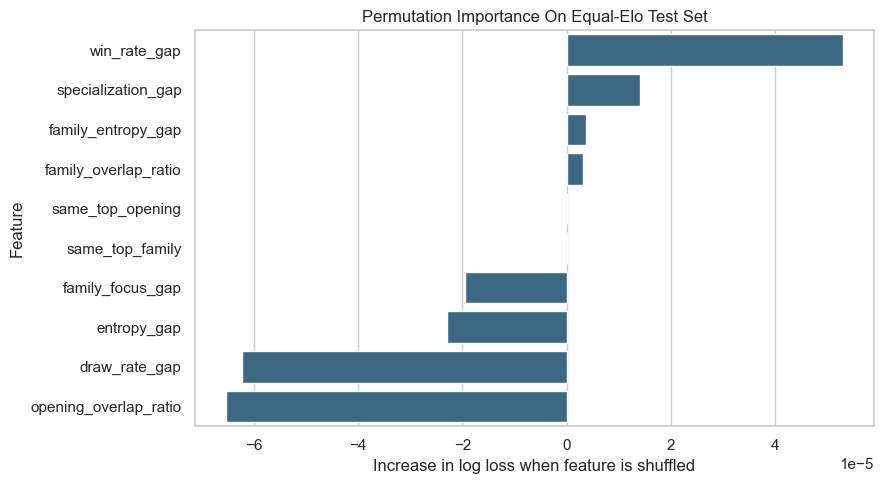

In [16]:
plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='log_loss_increase', y='feature', color='#2f6c8f')
plt.title('Permutation Importance On Equal-Elo Test Set')
plt.xlabel('Increase in log loss when feature is shuffled')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Save Outputs


In [17]:
results_df.to_csv(OUTPUT_DIR / 'equal_elo_test_predictions.csv', index=False)
summary_metrics.to_csv(OUTPUT_DIR / 'equal_elo_summary_metrics.csv', index=False)
importance_df.to_csv(OUTPUT_DIR / 'equal_elo_permutation_importance.csv', index=False)
search_df.to_csv(OUTPUT_DIR / 'equal_elo_model_search.csv', index=False)
train_df.to_csv(OUTPUT_DIR / 'equal_elo_train_dataset.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'equal_elo_test_dataset.csv', index=False)

plt.figure(figsize=(7, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.title('Confusion Matrix: Equal-Elo Outcome Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'equal_elo_confusion_matrix.png', dpi=200)
plt.close()

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='log_loss_increase', y='feature', color='#2f6c8f')
plt.title('Permutation Importance On Equal-Elo Test Set')
plt.xlabel('Increase in log loss when feature is shuffled')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'equal_elo_permutation_importance.png', dpi=200)
plt.close()

search_plot = search_df.head(15).copy()
search_plot['config'] = search_plot.index.astype(str)
plt.figure(figsize=(10, 5))
sns.barplot(data=search_plot, x='val_log_loss', y='config', color='#ad7c59')
plt.title('Top Validation Configurations')
plt.xlabel('Validation log loss')
plt.ylabel('Ranked configuration')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'equal_elo_model_search_top15.png', dpi=200)
plt.close()

print('Saved outputs to:')
print(OUTPUT_DIR)
print(PLOT_DIR)


Saved outputs to:
/Users/phamhoanghai/Ureca/Question_two/advanced_output
/Users/phamhoanghai/Ureca/Question_two/advanced_plots


In [18]:
summary_metrics


,metric,value
0,test_log_loss,0.835150
1,multiclass_brier_score,0.538323
